# Computer Vision
## Notebook 3a — I-JEPA Self-Supervised Pretraining on VisioDECT

| | |
|---|---|
| **Dataset** | **VisioDECT** (Part A cleaned image set, 20,603 images, labels **discarded** for SSL) |
| **SSL method** | **I-JEPA** — latent (representation-space) prediction of masked target blocks |
| **Encoder** | Backbone of **YOLOv26-s** — the Part A winner by test mAP50-95 (0.6489, 67.9 FPS) |
| **Framework** | `ssl-detection-lab` >= 0.8.1 (course package, github.com/rifat963/ssl-detection-lab) |
| **Downstream pair** | Notebook 3b loads this checkpoint and fine-tunes at the 20% label budget |

**Covers step in order:** CONFIG → environment → leakage-safe 10/10/80
partition (printed + verified) → masked-view demo → model definition + dry-run → 30-epoch
pretraining with loss curve → representation diagnostics (t-SNE + nearest-neighbour retrieval
+ commentary) → checkpoint export with the naming convention and Kaggle-dataset hand-off.

## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *Create* → *New Notebook* → File → Import Notebook.
2. **Settings**: Accelerator = **GPU T4 x2**; Internet = **On** (installs the course package
   from GitHub and downloads nothing else — pretraining starts from a randomly initialised
   YOLOv26-s backbone, as the assignment requires for I-JEPA).
3. **Attach the Part A Notebook 1,4 output**: *Add Input → Your Work →* the committed Part A
   **Notebook 1,4** → its Output. `visiodect_yolo/` must appear under `/kaggle/input/...`.
   Part B merges its three splits and **re-partitions 10/10/80 with the shared seed** — the
   Part A splits themselves are not reused.
4. **Version gate (course announcement)**: the install cell must print
   `ssl-detection-lab version: 0.8.1` **or newer**. If an older version appears:
   *Run → Restart & clear cell outputs*, then run all again from the top — the announcement
   documents this first-install quirk.
5. **Run all.** The §6 timing probe (1 epoch) prints a 30-epoch estimate — proceed if it fits
   a single session; the documented fallback levers are in CONFIG.
6. **Commit** (*Save Version → Save & Run All*), set **Public**, then create a **public Kaggle
   dataset** from this notebook's output (e.g. `groupXX-partb-ssl-checkpoints`) — Notebook 3b
   attaches that dataset and loads `ijepa_backbone.pt` from it (§10 prints the exact files).

## 1. CONFIG
Everything §4.1 requires declared once: method, encoder architecture, image size, batch size,
epochs, learning rate, masking parameters, and the **shared Part B seed** used by every
notebook for the partition and all subset sampling.

In [ ]:
# =============================== CONFIG ===============================

# ---- method & encoder --------------------------------------------------
SSL_METHOD  = "ijepa"
YOLO_ARCH   = "yolo26s.yaml"   # ARCHITECTURE ONLY (random init): the Part A winner was
                               # YOLOv26-s (test mAP50-95 0.6489 vs v12 0.6534? -> see memo:
                               # v26-s chosen as Part-A production pick for speed and 
                               # it is a strong choice for small object detection ;
                               # To selects v12-s instead, change this ONE string
                               # and the 3b pair accordingly).
# Integration route (assignment "Backbone Integration Strategy", viva Q4/Q5):
# the course package applies the I-JEPA objective directly to the YOLO CNN
# backbone -- context/target blocks are sampled on the backbone's final feature
# grid (image_size/32) and prediction happens in that latent space. This is the
# CNN-adaptation route: no ViT adapter is needed and the pretrained weights load
# layer-for-layer into YOLOv26-s in Notebook 3b.

# ---- Part B shared partition protocol ----------------------------------
PARTB_SEED   = 445    # ONE seed shared by ALL Part B notebooks: it fixes the
                      # 10/10/80 partition AND the nested label-fraction ranks.
TEST_FRAC    = 0.10
VAL_FRAC     = 0.10   # remaining 80% = SSL pool (labels discarded)

# ---- pretraining budget (assignment standard: 30 epochs) ----------------
FAST_RUN     = False  # True = smoke preset for pipeline checks only
EPOCHS       = 50
IMAGE_SIZE   = 224    # backbone grid = 224/32 = 7x7 for mask sampling; reduced
                      # from detection's 640 deliberately -- SSL learns features,
                      # not boxes, and 224 keeps 30 epochs inside one T4 session
                      # (documented per the assignment's budget note).
BATCH_SIZE   = 16     # per GPU; T4 x2 + grad accumulation -> effective 64
GRAD_ACCUM   = 2
WORKERS      = 4
LR, MIN_LR   = 3e-4, 3e-6      # cosine decay inside the package
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 2
GRAD_CLIP    = 5.0
AMP          = True   # fp16 autocast on the T4 (documented budget lever)

# ---- I-JEPA masking / heads (tutorial full preset) -----------------------
PROJECTION_DIM    = 256
EMA_MOMENTUM      = 0.996   # target encoder EMA, annealed to FINAL_MOMENTUM
FINAL_MOMENTUM    = 1.0
NUM_TARGET_BLOCKS = 4
TARGET_SCALE      = (0.10, 0.25)   # block area as a fraction of the 7x7 grid
TARGET_ASPECT     = (0.75, 1.50)
PREDICTOR_DEPTH   = 2
PREDICTOR_HEADS   = 4

# ---- probe & paths -------------------------------------------------------
TIMING_PROBE = True   # 1-epoch probe before the full run (Part A discipline)
NB1_DIR_MANUAL = None # e.g. Path("/kaggle/input/<nb1-slug>/visiodect_yolo")
WORK_ROOT   = "/kaggle/working"
SSL_POOL_DIR = f"{WORK_ROOT}/ssl_pool"            # symlinked 80% images
OUTPUT_DIR   = f"{WORK_ROOT}/ijepa_yolo26s_visiodect"
PROBE_DIR    = f"{WORK_ROOT}/ijepa_probe"
PARTITION_CSV = f"{WORK_ROOT}/partB_partition.csv" # shared by 3b/all notebooks
CKPT_BACKBONE = f"{WORK_ROOT}/ijepa_backbone.pt"          # §7 naming convention
CKPT_YOLO     = f"{WORK_ROOT}/ijepa_yolo26s_backbone.pt"  # YOLO-format copy for 3b

if FAST_RUN:   # smoke preset -- never commit with this on
    EPOCHS, IMAGE_SIZE, BATCH_SIZE, GRAD_ACCUM = 2, 160, 8, 1
    NUM_TARGET_BLOCKS, PROJECTION_DIM, PREDICTOR_DEPTH = 2, 128, 1

print(f"CONFIG | {SSL_METHOD} on {YOLO_ARCH} | {EPOCHS} epochs @ {IMAGE_SIZE}px "
      f"| batch {BATCH_SIZE}x{GRAD_ACCUM}/GPU | seed {PARTB_SEED} "
      f"| checkpoint -> {CKPT_BACKBONE}")


CONFIG | ijepa on yolo26s.yaml | 50 epochs @ 224px | batch 16x2/GPU | seed 445 | checkpoint -> /kaggle/working/ijepa_backbone.pt


## 2. Environment — install the course package and gate the version
Per the course announcement: rerun this cell after any restart and confirm it prints
**version 0.8.1 or newer**; if an older version appears, restart the session and rerun from
the top.

In [2]:
%pip install -q --no-cache-dir --force-reinstall --no-deps "git+https://github.com/rifat963/ssl-detection-lab.git@main" ultralytics


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from dataclasses import replace
from importlib.metadata import version as installed_version
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from packaging.version import Version
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from tqdm.auto import tqdm
from ultralytics import YOLO

_v = installed_version("ssl-detection-lab")
print(f"ssl-detection-lab version: {_v}")
assert Version(_v) >= Version("0.8.1"), (
    "Older ssl-detection-lab detected. Per the course announcement: restart the "
    "session (Run -> Restart & clear cell outputs) and rerun the install cell first.")

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform
from ssldet.ssl import create_ssl_module, sample_target_blocks

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED)
torch.manual_seed(PARTB_SEED); torch.cuda.manual_seed_all(PARTB_SEED)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

GPU_COUNT = max(1, torch.cuda.device_count())
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(pd.Series({"ssl-detection-lab": ssldet.__version__, "PyTorch": torch.__version__,
                 "GPUs": GPU_COUNT if torch.cuda.is_available() else "CPU (smoke only)"}))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
ssl-detection-lab           0.9.0
PyTorch              2.10.0+cu128
GPUs                            2
dtype: object


## 3. Leakage-Safe 10/10/80 Partition (shared by every SSL notebook)
The Part A splits are **not reused**: all 20,603 cleaned images are merged and re-partitioned
once, at image level, with the shared seed — 10% test holdout, 10% validation, 80% SSL pool.
This cell **prints the partition sizes** and **verifies by filename intersection** that test
and validation are disjoint from the SSL pool (both are assignment mandates). It also assigns
every pool image a seeded `pool_rank`, so the 20% fine-tuning subset (Notebook 3b) and the
bonus 10–50% budgets are **nested by construction** — budget ρ is simply
`pool_rank < ρ·|D|`. The manifest is exported for hand-off so every notebook provably uses
the identical partition.

**Why this is not leakage :** SSL pretraining never reads annotations, so no label
information can leak; fine-tuning images legitimately overlap the SSL pool (the standard
SimCLR/BYOL label-efficiency protocol); leakage would require test/val pixels in the pool,
labels influencing pretraining, or test-driven tuning — the checks below rule out the first
and the pipeline never does the other two.

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not the NB1 output: {p}")
    base, stack = Path("/kaggle/input"), []
    stack.append((base, 0))
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/) as input.")

NB1_ROOT = find_nb1_root()
all_images = sorted(p for s in ("train", "val", "test")
                    for p in (NB1_ROOT / s / "images").rglob("*")
                    if p.is_file() and p.suffix.lower() in IMG_EXTS)
N = len(all_images)
print(f"NB1 root: {NB1_ROOT}\nMerged Part A images: {N:,}")

# ---- one seeded shuffle drives everything -----------------------------------
names = [p.name for p in all_images]
assert len(set(names)) == N, "filename collision across NB1 splits!"
order = list(range(N))
random.Random(PARTB_SEED).shuffle(order)
n_test, n_val = round(TEST_FRAC * N), round(VAL_FRAC * N)
test_idx = set(order[:n_test])
val_idx  = set(order[n_test:n_test + n_val])
pool_pos = order[n_test + n_val:]                 # shuffled order -> nested budgets

rows, pool_rank = [], {i: r for r, i in enumerate(pool_pos)}
for i, p in enumerate(all_images):
    part = "test" if i in test_idx else "val" if i in val_idx else "ssl_pool"
    rows.append({"filename": p.name, "source_path": str(p), "partition": part,
                 "pool_rank": pool_rank.get(i, -1)})
partition = pd.DataFrame(rows)
partition.to_csv(PARTITION_CSV, index=False)

sizes = partition.partition.value_counts()
print(f"\nPartition sizes (seed {PARTB_SEED}):")
print(sizes.to_string())
print(f"20% fine-tune budget for 3b = pool_rank < {round(0.20 * N):,} "
      f"(nested; bonus budgets use the same ranks)")

# ---- mandated disjointness verification (filename intersections) ------------
sets = {k: set(partition[partition.partition == k].filename)
        for k in ("test", "val", "ssl_pool")}
assert not (sets["test"] & sets["ssl_pool"]), "TEST leaked into SSL pool!"
assert not (sets["val"]  & sets["ssl_pool"]), "VAL leaked into SSL pool!"
assert not (sets["test"] & sets["val"]),      "TEST/VAL overlap!"
assert sum(map(len, sets.values())) == N
print("\n[OK] Disjointness verified by filename intersection: "
      "test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0")


NB1 root: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
Merged Part A images: 20,603

Partition sizes (seed 445):
partition
ssl_pool    16483
test         2060
val          2060
20% fine-tune budget for 3b = pool_rank < 4,121 (nested; bonus budgets use the same ranks)

[OK] Disjointness verified by filename intersection: test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0


In [5]:
# ---- materialise the SSL pool as a directory (labels never copied) ----------
pool_dir = Path(SSL_POOL_DIR)
if pool_dir.exists():
    shutil.rmtree(pool_dir)
pool_dir.mkdir(parents=True)
for _, r in tqdm(partition[partition.partition == "ssl_pool"].iterrows(),
                 total=len(sets["ssl_pool"]), desc="linking SSL pool"):
    dst = pool_dir / r.filename
    try:
        os.symlink(r.source_path, dst)
    except OSError:
        shutil.copy2(r.source_path, dst)

pool_images = sorted(p for p in pool_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
assert len(pool_images) == len(sets["ssl_pool"])
print(f"SSL pool directory ready: {len(pool_images):,} images "
      "(image files only — no label file is ever read in this notebook)")


linking SSL pool:   0%|          | 0/16483 [00:00<?, ?it/s]

SSL pool directory ready: 16,483 images (image files only — no label file is ever read in this notebook)


## 4. Method-Specific Views — the Masked-Prediction 
I-JEPA uses **no hand-crafted augmentations** : the transform below is only
resize/crop/normalise, and the learning signal comes from **masking** instead — target blocks
are sampled on the backbone's final feature grid (`image_size/32`), their union is hidden
from the **context encoder**, and a predictor must infer the **target encoder's latent
representations** of the hidden blocks (viva Q1/Q2: prediction in representation space, and
targets must be masked out of the context or the task collapses into copying).

In [6]:
ssl_config = PretrainConfig(
    method=SSL_METHOD,
    image_roots=[str(SSL_POOL_DIR)],          # the 80% pool ONLY (verified above)
    output_dir=str(OUTPUT_DIR),
    yolo_model=YOLO_ARCH,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    workers=WORKERS, max_images=None, seed=PARTB_SEED,
    learning_rate=LR, min_learning_rate=MIN_LR, weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS, grad_accum_steps=GRAD_ACCUM,
    gradient_clip=GRAD_CLIP, amp=AMP,
    projection_dim=PROJECTION_DIM,
    momentum=EMA_MOMENTUM, final_momentum=FINAL_MOMENTUM,
    num_target_blocks=NUM_TARGET_BLOCKS,
    target_scale_min=TARGET_SCALE[0], target_scale_max=TARGET_SCALE[1],
    target_aspect_min=TARGET_ASPECT[0], target_aspect_max=TARGET_ASPECT[1],
    predictor_depth=PREDICTOR_DEPTH, predictor_heads=PREDICTOR_HEADS,
    save_every=1,
).validate()
print("PretrainConfig validated | grid for mask sampling:",
      f"{IMAGE_SIZE // 32} x {IMAGE_SIZE // 32}")


PretrainConfig validated | grid for mask sampling: 7 x 7


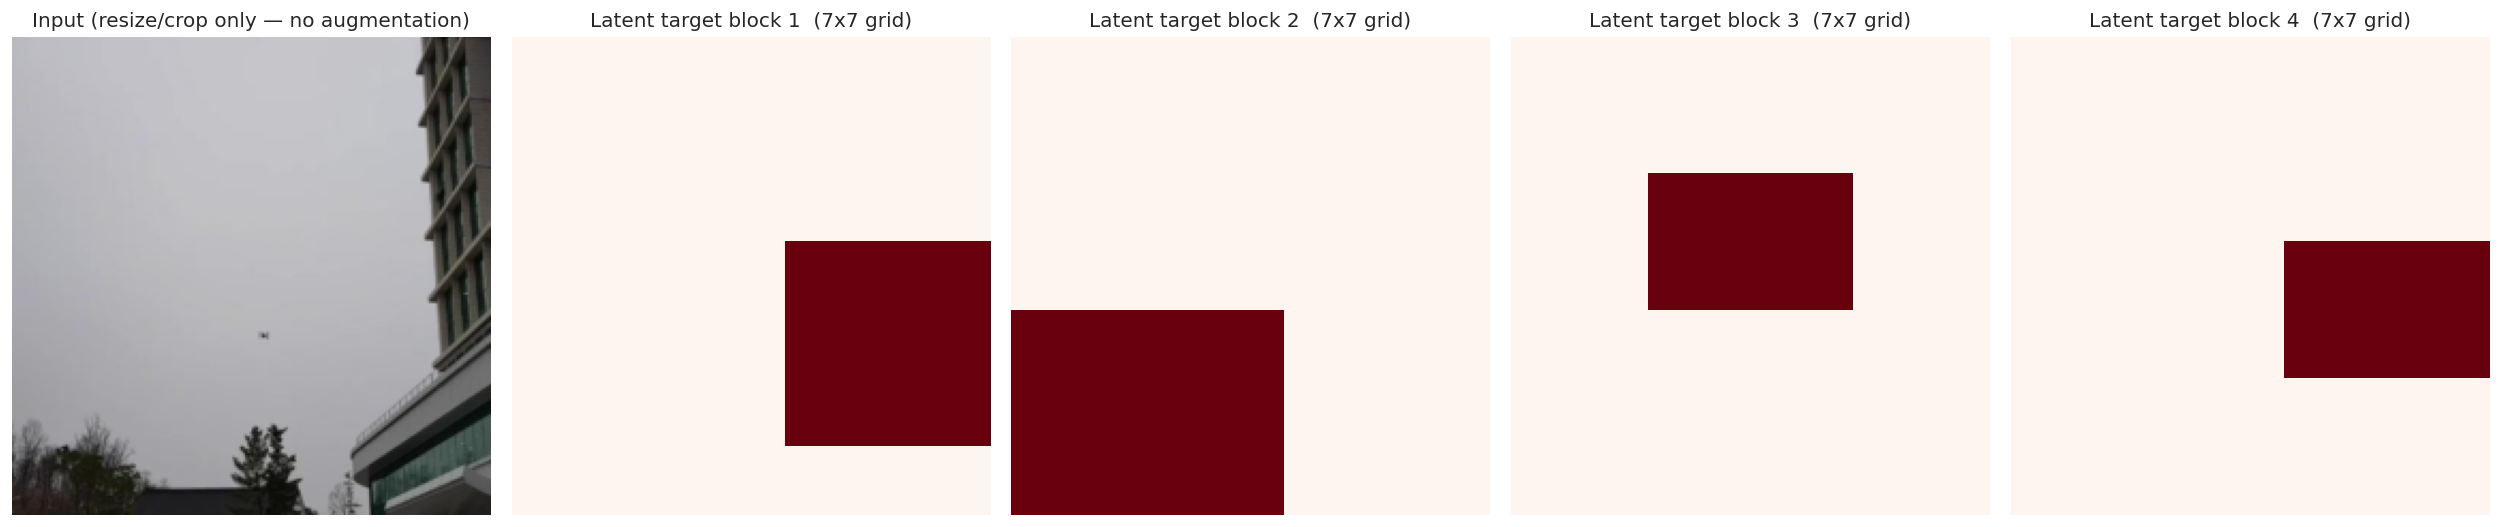

During training the UNION of these blocks is hidden from the context encoder; the predictor must reconstruct the target encoder's representations of them.


In [7]:
# ---- single-image demo: input + latent target blocks ------------------------
preview_dataset = UnlabeledImageDataset(pool_images, build_transform(ssl_config))
preview = preview_dataset[0]
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
display_image = (preview * std + mean).clamp(0, 1).permute(1, 2, 0)

grid = ssl_config.image_size // 32
masks = sample_target_blocks(
    1, grid, grid, ssl_config.num_target_blocks,
    (ssl_config.target_scale_min, ssl_config.target_scale_max),
    (ssl_config.target_aspect_min, ssl_config.target_aspect_max),
    torch.device("cpu"))[0]

fig, axes = plt.subplots(1, ssl_config.num_target_blocks + 1,
                         figsize=(4.2 * (ssl_config.num_target_blocks + 1), 4.4))
axes[0].imshow(display_image); axes[0].set_title("Input (resize/crop only — no augmentation)")
for k, m in enumerate(masks, start=1):
    axes[k].imshow(m, cmap="Reds", vmin=0, vmax=1)
    axes[k].set_title(f"Latent target block {k}  ({grid}x{grid} grid)")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()
print("During training the UNION of these blocks is hidden from the context encoder; "
      "the predictor must reconstruct the target encoder's representations of them.")


## 5. Model Definition + Dry Run 
Context encoder = the **YOLOv26-s backbone** (randomly initialised — the assignment requires
running the I-JEPA objective ourselves); target encoder = its **EMA copy** (frozen to
gradients, momentum 0.996 → 1.0); plus a lightweight attention **predictor** operating on the
7×7 latent grid. One forward pass prints the feature width and an untrained example loss —
proof the pipeline is wired before any GPU-hours are spent.

In [8]:
probe_detector = YOLO(ssl_config.yolo_model)
probe_encoder  = YOLOBackboneEncoder(probe_detector.model).to(DEVICE)
feature_channels, _, _ = probe_encoder.infer_dimensions(ssl_config.image_size, DEVICE)
ijepa_module = create_ssl_module(
    SSL_METHOD, encoder=probe_encoder, feature_channels=feature_channels,
    projection_dim=ssl_config.projection_dim,
    predictor_depth=ssl_config.predictor_depth,
    predictor_heads=ssl_config.predictor_heads,
    momentum=ssl_config.momentum,
    num_target_blocks=ssl_config.num_target_blocks,
    target_scale=(ssl_config.target_scale_min, ssl_config.target_scale_max),
    target_aspect=(ssl_config.target_aspect_min, ssl_config.target_aspect_max),
).to(DEVICE)

amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    example_loss = ijepa_module(preview.unsqueeze(0).to(DEVICE))

print(pd.Series({
    "encoder": f"YOLOv26-s backbone ({sum(p.numel() for p in probe_encoder.parameters())/1e6:.1f} M params)",
    "feature channels": feature_channels,
    "untrained example loss": round(float(example_loss), 4),
    "target encoder trainable": any(p.requires_grad for p in ijepa_module.target_encoder.parameters()),
}))
del ijepa_module, probe_encoder, probe_detector, example_loss
torch.cuda.empty_cache()


encoder                     YOLOv26-s backbone (5.4 M params)
feature channels                                          512
untrained example loss                                 0.7205
target encoder trainable                                False
dtype: object


## 6. 1-Epoch Timing Probe 
The assignment mandates the 30-epoch run fit one T4 session and allows documented budget
levers (resolution, AMP). This probe measures one real epoch through the launcher and
extrapolates ×30 — the same measure-before-commit protocol that saved Part A twice.

In [9]:
if TIMING_PROBE:
    probe_cfg = replace(ssl_config, epochs=1, warmup_epochs=0,
                        output_dir=str(PROBE_DIR)).validate()
    t0 = time.time()
    launch_distributed_pretrain(probe_cfg, num_processes=GPU_COUNT,
                                config_path=Path(PROBE_DIR) / "probe_config.yaml", check=True)
    probe_min = (time.time() - t0) / 60
    est = probe_min * EPOCHS
    print(f"\nProbe epoch: {probe_min:.1f} min -> {EPOCHS}-epoch estimate: "
          f"{est:.0f} min ({est/60:.1f} h)")
    print("[OK] Fits a single session." if est <= 9 * 60 else
          "[!] OVER BUDGET — documented levers, in order: IMAGE_SIZE 224 -> 192 "
          "(grid 6x6), BATCH_SIZE up if VRAM allows (fewer steps), then epochs "
          "reduction applied identically to ALL four SSL methods (assignment rule).")
    shutil.rmtree(PROBE_DIR, ignore_errors=True)
else:
    print("Timing probe skipped (TIMING_PROBE=False).")


IJEPA 01/01: 100%|██████████| 515/515 [03:38<00:00,  2.36it/s, ema=1.00000, loss=0.0252, lr=3.01e-06]


Epoch 01 | loss=0.02523 | time=218.1s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/ijepa_probe",
  "yolo_checkpoint": "/kaggle/working/ijepa_probe/ijepa_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_probe/history.csv",
  "manifest_json": "/kaggle/working/ijepa_probe/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/ijepa_probe",
  "yolo_checkpoint": "/kaggle/working/ijepa_probe/ijepa_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_probe/history.csv",
  "manifest_json": "/kaggle/working/ijepa_probe/run_manifest.json"
}

Probe epoch: 4.0 min -> 50-epoch estimate: 199 min (3.3 h)
[OK] Fits a single session.


## 7. Full Pretraining — 50 Epochs 
`launch_distributed_pretrain` spawns one process per GPU (T4 x2) via
`torch.distributed.run`; loss is logged per epoch to `history.csv`. **No label file is opened
anywhere in this run** — the dataset class reads pixels only.

In [10]:
t0 = time.time()
training_result = launch_distributed_pretrain(
    ssl_config, num_processes=GPU_COUNT,
    config_path=Path(OUTPUT_DIR) / "ijepa_config.yaml", check=True)
TRAIN_MINUTES = (time.time() - t0) / 60
print(f"\nPretraining wall time: {TRAIN_MINUTES:.1f} min")
print(training_result)


IJEPA 01/50: 100%|██████████| 515/515 [03:41<00:00,  2.33it/s, ema=0.99600, loss=0.2163, lr=1.51e-04]


Epoch 01 | loss=0.21766 | time=221.4s


IJEPA 02/50: 100%|██████████| 515/515 [03:08<00:00,  2.73it/s, ema=0.99602, loss=0.0320, lr=3.00e-04]


Epoch 02 | loss=0.03242 | time=188.5s


IJEPA 03/50: 100%|██████████| 515/515 [03:12<00:00,  2.67it/s, ema=0.99604, loss=0.0174, lr=3.00e-04]


...

Epoch 49 | loss=0.10446 | time=201.5s


IJEPA 50/50: 100%|██████████| 515/515 [03:21<00:00,  2.56it/s, ema=1.00000, loss=0.1049, lr=3.00e-06]


Epoch 50 | loss=0.10429 | time=201.3s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/ijepa_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/ijepa_yolo26s_visiodect/ijepa_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/ijepa_yolo26s_visiodect/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/ijepa_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/ijepa_yolo26s_visiodect/ijepa_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/ijepa_yolo26s_visiodect/run_manifest.json"
}

Pretraining wall time: 167.7 min
DistributedPretrainResult(config_path=PosixPath('/kaggle/working/ijepa_yolo26s_visiodect/ijepa_config.yaml'), output_dir=PosixPath('/kaggle/working/ijepa_yolo26s_visiodect'), command=('/usr/bin/python3', 

### 7.1 Loss Curve and Run Manifest 

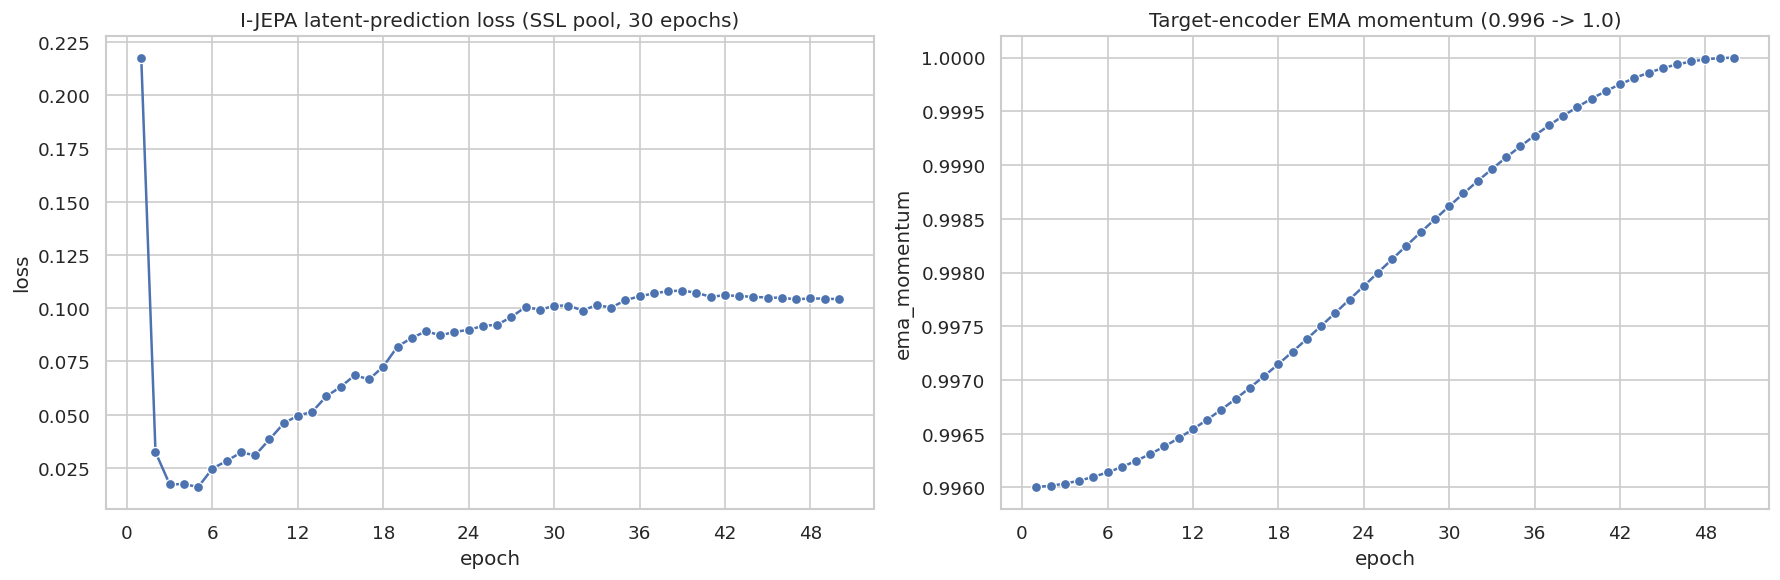

best SSL checkpoint                /kaggle/working/ijepa_yolo26s_visiodect/best_s...
YOLO-format backbone checkpoint    /kaggle/working/ijepa_yolo26s_visiodect/ijepa_...
best loss                                                                    0.01604
unlabelled images seen                                                         16483
world size (GPUs)                                                                  2
dtype: object
[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less


In [11]:
history  = pd.read_csv(Path(OUTPUT_DIR) / "history.csv")
manifest = json.loads((Path(OUTPUT_DIR) / "run_manifest.json").read_text())
BEST_SSL = Path(OUTPUT_DIR) / "best_ssl.pt"
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", ax=axes[0])
axes[0].set_title("I-JEPA latent-prediction loss (SSL pool, 30 epochs)")
if "ema_momentum" in history:
    sns.lineplot(data=history, x="epoch", y="ema_momentum", marker="o", ax=axes[1])
    axes[1].set_title("Target-encoder EMA momentum (0.996 -> 1.0)")
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/ijepa_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.Series({
    "best SSL checkpoint": str(BEST_SSL),
    "YOLO-format backbone checkpoint": str(YOLO_CHECKPOINT),
    "best loss": manifest["best_loss"],
    "unlabelled images seen": manifest["unlabeled_images"],
    "world size (GPUs)": manifest["world_size"],
}))
assert manifest["unlabeled_images"] == len(pool_images), \
    "trainer saw a different image count than the verified SSL pool!"
print("[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less")


## 8. Representation Diagnostics 
Embeddings are extracted for a **500-image sample of the validation partition** (never seen
during pretraining) with the trained backbone. VisioDECT's filenames encode
`Class_scenario_original`, so the t-SNE can be coloured two ways — by **drone class** (does
the representation organise target-class content?) and by **scenario** (or does it organise
by lighting instead — an equally honest finding). The retrieval panels and a quantitative
top-5 neighbour class-agreement score back the visual impression. Labels are used here for
**colouring diagnostics only, after training** — pretraining never saw them.

In [12]:
SCENARIOS = ["cloudy", "evening", "sunny"]
CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]

def parse_stem(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            rest = stem[len(c) + 1:]
            scen = rest.split("_")[0]
            return c, scen if scen in SCENARIOS else "unknown"
    return "unknown", "unknown"

val_rows = partition[partition.partition == "val"]
sel = val_rows.sample(min(500, len(val_rows)), random_state=PARTB_SEED)
sel_paths  = [Path(p) for p in sel.source_path]
sel_class  = [parse_stem(Path(p).stem)[0] for p in sel.source_path]
sel_scen   = [parse_stem(Path(p).stem)[1] for p in sel.source_path]

feature_transform = v2.Compose([
    v2.Resize(ssl_config.image_size + 32, antialias=True),
    v2.CenterCrop(ssl_config.image_size),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class FeatureDataset(Dataset):
    def __len__(self):
        return len(sel_paths)
    def __getitem__(self, i):
        with Image.open(sel_paths[i]) as im:
            return feature_transform(im.convert("RGB")), i

encoder = YOLOBackboneEncoder(YOLO(str(YOLO_CHECKPOINT)).model).to(DEVICE).eval()
loader = DataLoader(FeatureDataset(), batch_size=64, shuffle=False,
                    num_workers=min(2, WORKERS), pin_memory=DEVICE.type == "cuda")
feats = []
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    for images, _ in tqdm(loader, desc="extracting I-JEPA features (val sample)"):
        f = encoder(images.to(DEVICE, non_blocking=True))
        feats.append(F.normalize(f.float(), dim=1).cpu())
feature_matrix = torch.cat(feats)
print(f"features: {tuple(feature_matrix.shape)} | "
      f"mean per-dim std: {feature_matrix.std(dim=0).mean():.4f} "
      "(a healthy non-collapsed representation has clearly non-zero spread)")


extracting I-JEPA features (val sample):   0%|          | 0/8 [00:00<?, ?it/s]

features: (500, 512) | mean per-dim std: 0.0378 (a healthy non-collapsed representation has clearly non-zero spread)


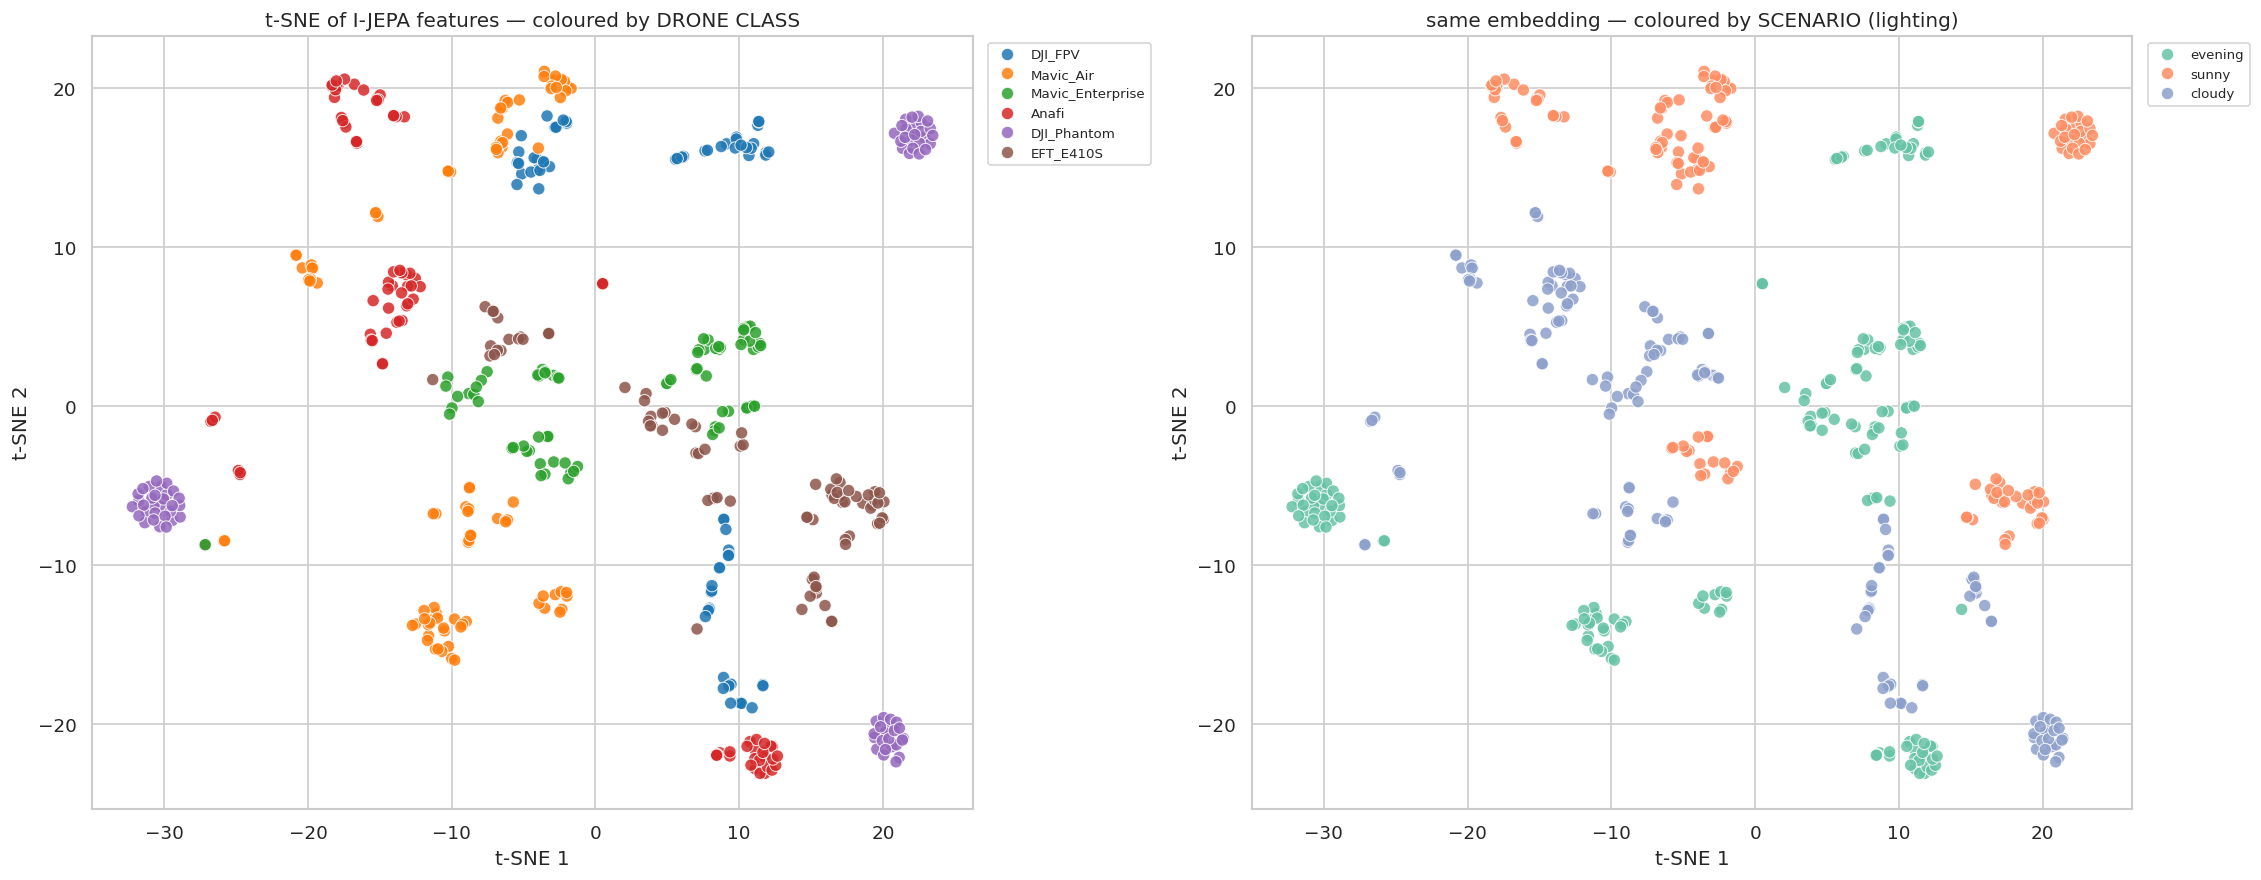

top-5 neighbour agreement — class: 95.0% (chance ~16.7%) | scenario: 97.5% (chance ~33.3%)


In [13]:
# ---- t-SNE coloured by class AND by scenario --------------------------------
perp = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
coords = TSNE(n_components=2, perplexity=perp, learning_rate="auto",
              init="pca", max_iter=1000, random_state=PARTB_SEED
              ).fit_transform(feature_matrix.numpy())
frame = pd.DataFrame({"t-SNE 1": coords[:, 0], "t-SNE 2": coords[:, 1],
                      "class": sel_class, "scenario": sel_scen})
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="class",
                palette="tab10", s=55, alpha=0.85, ax=axes[0])
axes[0].set_title("t-SNE of I-JEPA features — coloured by DRONE CLASS")
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="scenario",
                palette="Set2", s=55, alpha=0.85, ax=axes[1])
axes[1].set_title("same embedding — coloured by SCENARIO (lighting)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/ijepa_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# quantitative check: do top-5 neighbours share the query's class?
sims = feature_matrix @ feature_matrix.T
sims.fill_diagonal_(-1)
top5 = sims.topk(5, dim=1).indices
agree = np.mean([[sel_class[j] == sel_class[i] for j in row.tolist()]
                 for i, row in enumerate(top5)])
scen_agree = np.mean([[sel_scen[j] == sel_scen[i] for j in row.tolist()]
                      for i, row in enumerate(top5)])
print(f"top-5 neighbour agreement — class: {agree:.1%} (chance ~16.7%) | "
      f"scenario: {scen_agree:.1%} (chance ~33.3%)")


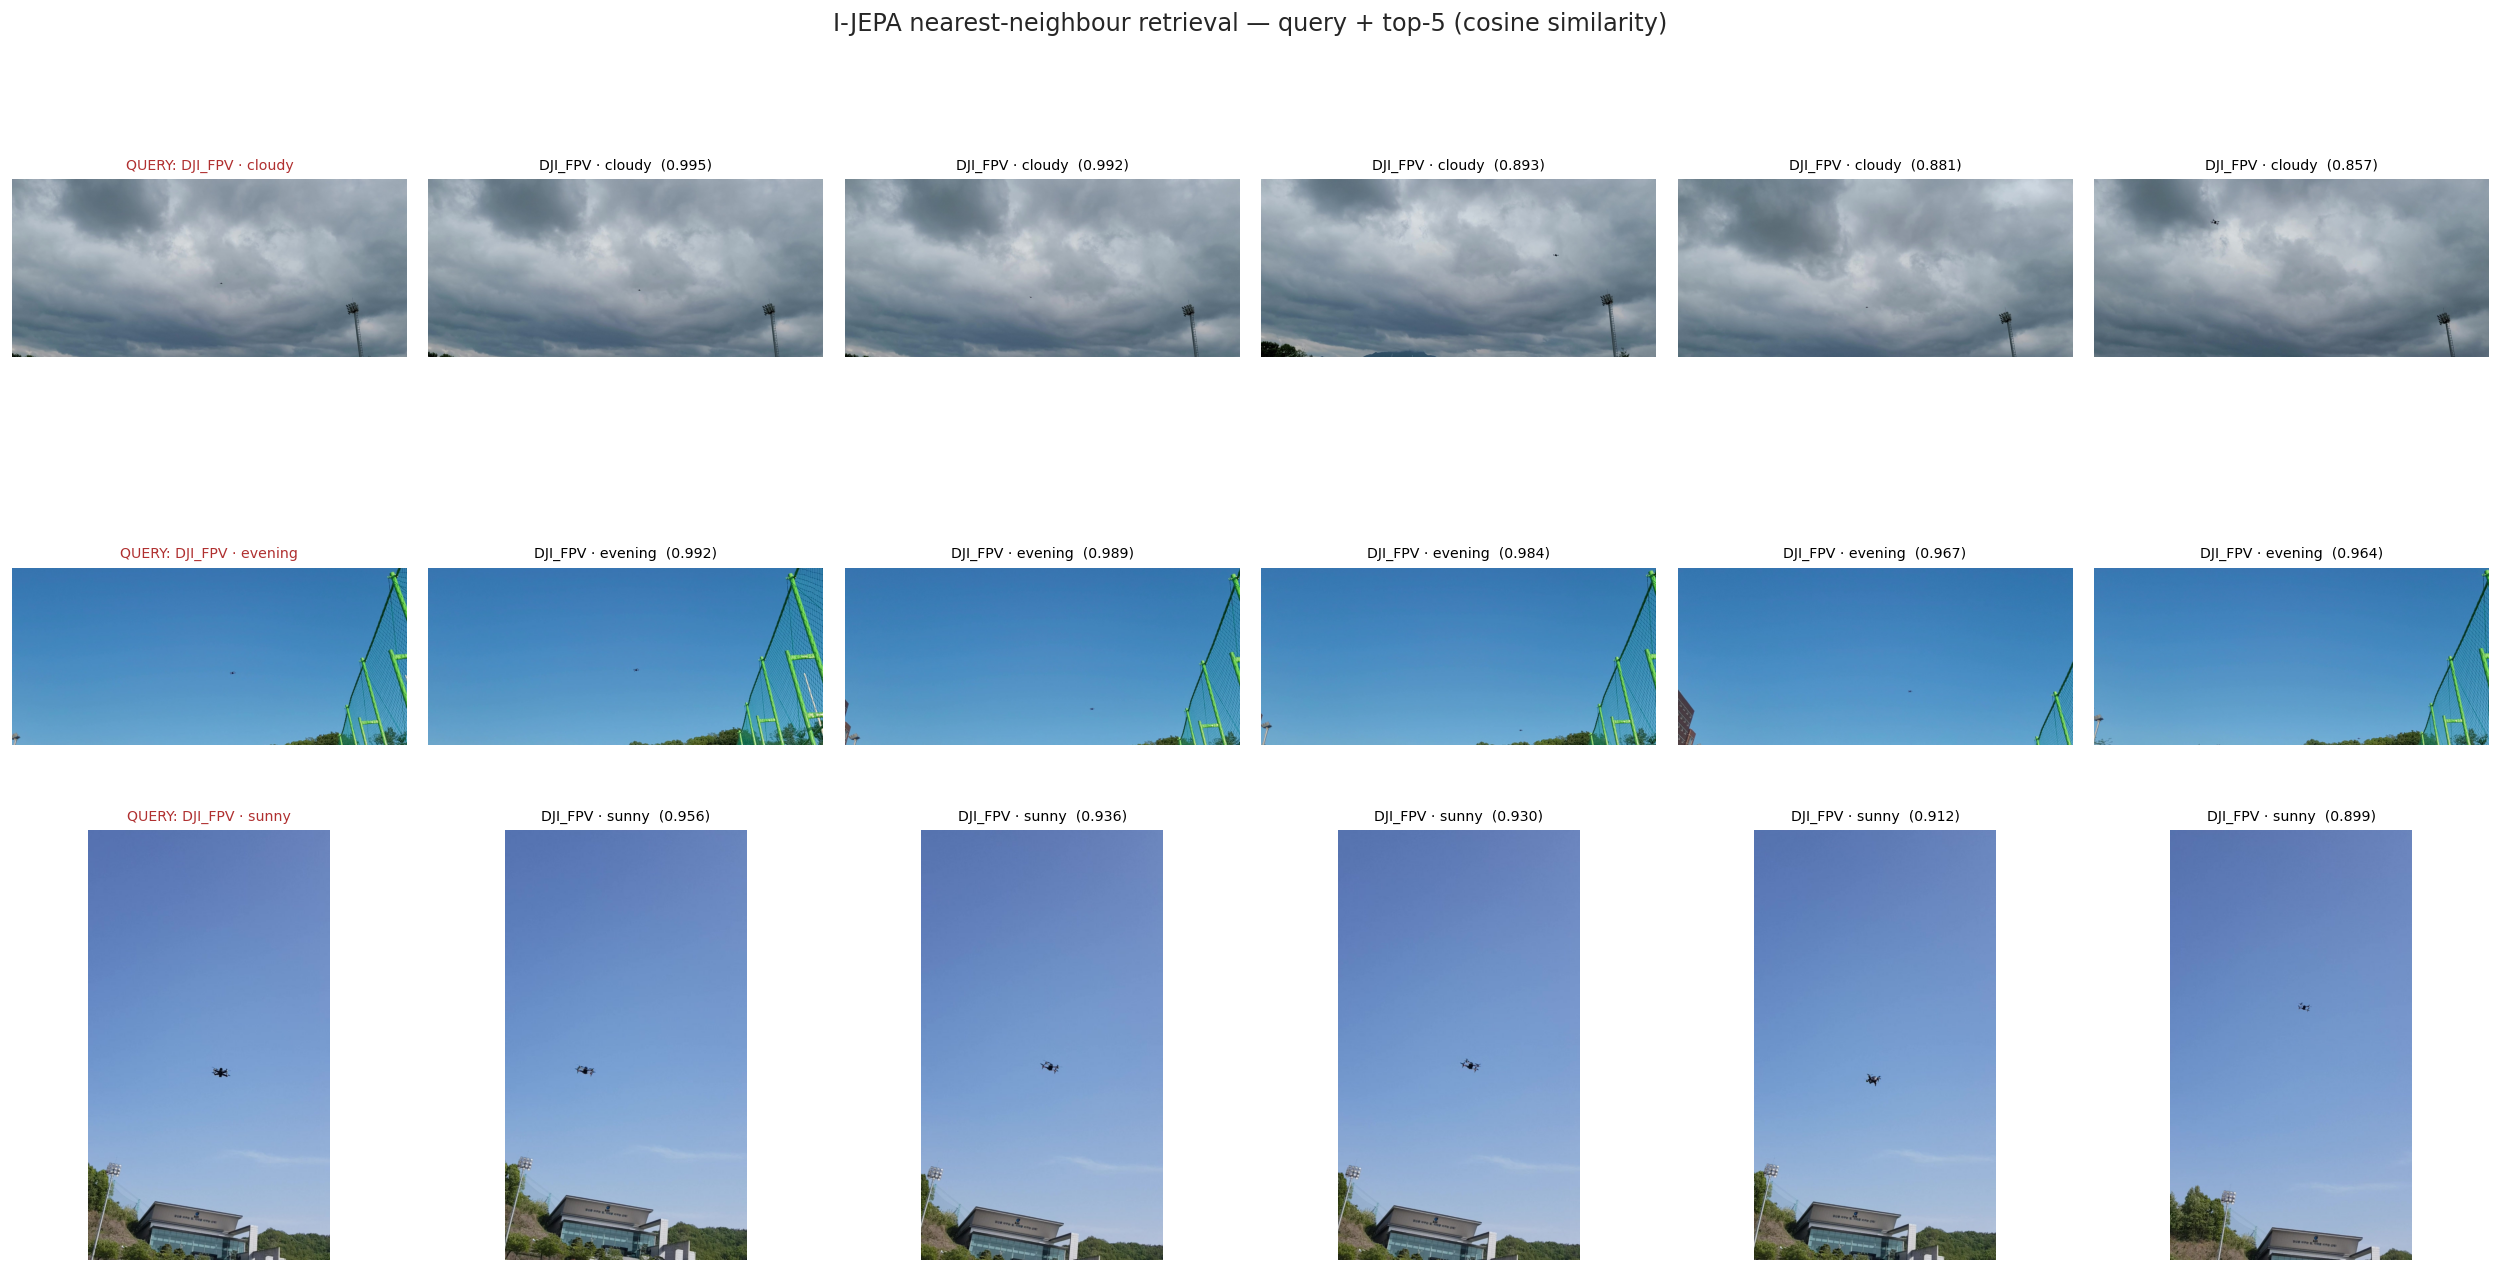

In [14]:
# ---- nearest-neighbour retrieval panels (one query per scenario) ------------
queries = [i for scen in SCENARIOS
           for i in [next((k for k, s in enumerate(sel_scen) if s == scen), None)]
           if i is not None] or [0]
fig, axes = plt.subplots(len(queries), 6, figsize=(21, 3.6 * len(queries)))
axes = np.atleast_2d(axes)
for row, q in enumerate(queries):
    nn = [j for j in sims[q].topk(6).indices.tolist() if j != q][:5]
    for col, idx in enumerate([q] + nn):
        ax = axes[row, col]
        with Image.open(sel_paths[idx]) as im:
            ax.imshow(im.convert("RGB"))
        ax.axis("off")
        ax.set_title("QUERY: " + f"{sel_class[idx]} · {sel_scen[idx]}" if col == 0
                     else f"{sel_class[idx]} · {sel_scen[idx]}  ({sims[q][idx]:.3f})",
                     fontsize=8.5, color="#b03030" if col == 0 else "black")
plt.suptitle("I-JEPA nearest-neighbour retrieval — query + top-5 (cosine similarity)")
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/ijepa_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Checkpoint Export + Kaggle Dataset Hand-off 
| File in `/kaggle/working/` | Purpose |
|---|---|
| **`ijepa_backbone.pt`** | §7-convention SSL checkpoint (copy of `best_ssl.pt`) |
| **`ijepa_yolo26s_backbone.pt`** | YOLO-format backbone — what Notebook 3b actually loads |
| `partB_partition.csv` | The shared 10/10/80 partition + nested pool ranks — 3b and every other Part B notebook must consume THIS file |
| `ijepa_loss_curve.png`, `ijepa_tsne.png`, `ijepa_retrieval.png` | Report figures (§5.1 of the report) |
| `ijepa_yolo26s_visiodect/` | Full run dir: config yaml, history.csv, run_manifest.json, checkpoints |


In [15]:
shutil.copy2(BEST_SSL, CKPT_BACKBONE)
shutil.copy2(YOLO_CHECKPOINT, CKPT_YOLO)
summary = {
    "method": SSL_METHOD, "encoder": "YOLOv26-s backbone (random init)",
    "epochs": EPOCHS, "image_size": IMAGE_SIZE,
    "effective_batch": BATCH_SIZE * GRAD_ACCUM * GPU_COUNT,
    "seed": PARTB_SEED, "ssl_pool_images": len(pool_images),
    "best_loss": manifest["best_loss"], "train_minutes": round(TRAIN_MINUTES, 1),
    "checkpoint_backbone": CKPT_BACKBONE, "checkpoint_yolo": CKPT_YOLO,
    "partition_manifest": PARTITION_CSV,
}
Path(f"{WORK_ROOT}/ijepa_pretrain_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
for f in [CKPT_BACKBONE, CKPT_YOLO, PARTITION_CSV]:
    q = Path(f)
    print(f"[OK] {q.name:<30} {q.stat().st_size/1e6:>8.1f} MB" if q.exists() else f"MISSING {f}")


{
  "method": "ijepa",
  "encoder": "YOLOv26-s backbone (random init)",
  "epochs": 50,
  "image_size": 224,
  "effective_batch": 64,
  "seed": 445,
  "ssl_pool_images": 16483,
  "best_loss": 0.016039776122559187,
  "train_minutes": 167.7,
  "checkpoint_backbone": "/kaggle/working/ijepa_backbone.pt",
  "checkpoint_yolo": "/kaggle/working/ijepa_yolo26s_backbone.pt",
  "partition_manifest": "/kaggle/working/partB_partition.csv"
}
[OK] ijepa_backbone.pt                 108.6 MB
[OK] ijepa_yolo26s_backbone.pt          20.4 MB
[OK] partB_partition.csv                 4.6 MB


## 10. Pre-Commit Checklist 
- [ ] Install cell printed **ssl-detection-lab version >= 0.8.1** (restart + rerun if not)
- [ ] Partition sizes printed; disjointness verification printed `[OK]`
- [ ] Masked-view demo, dry-run loss, probe estimate, 50-epoch loss curve all visible
- [ ] Trainer image count matched the verified pool (`[OK]` assertion)
- [ ] t-SNE (class + scenario), retrieval panels, agreement percentages visible; §8.1 written
- [ ] `ijepa_backbone.pt`, `ijepa_yolo26s_backbone.pt`, `partB_partition.csv` printed `[OK]`
- [ ] Committed Public; output published as the checkpoint Kaggle dataset for 3b
